# Importing data

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('district_prices_monthly_old.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year_month                    9804 non-null   object 
 1   district                      9804 non-null   object 
 2   okrug                         9804 non-null   object 
 3   secondary_price_per_sqm       9804 non-null   int64  
 4   newbuild_price_per_sqm        9804 non-null   int64  
 5   rental_price_per_sqm_monthly  9804 non-null   int64  
 6   secondary_mom_change_pct      9675 non-null   float64
 7   newbuild_mom_change_pct       9675 non-null   float64
 8   n_listings_secondary          9804 non-null   int64  
 9   n_listings_newbuild           9804 non-null   int64  
 10  n_listings_rental             9804 non-null   int64  
 11  cbr_key_rate_pct              9804 non-null   float64
 12  avg_mortgage_rate_pct         9804 non-null   float64
dtypes: 

In [6]:
df2=pd.read_csv('rentals.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20000 non-null  object 
 1   date_posted         20000 non-null  object 
 2   district            20000 non-null  object 
 3   okrug               20000 non-null  object 
 4   lat                 20000 non-null  float64
 5   lon                 20000 non-null  float64
 6   total_area          20000 non-null  float64
 7   rooms               20000 non-null  int64  
 8   floor               20000 non-null  int64  
 9   total_floors        20000 non-null  int64  
 10  building_year       20000 non-null  int64  
 11  building_type       20000 non-null  object 
 12  renovation          20000 non-null  object 
 13  furnished           20000 non-null  bool   
 14  pets_allowed        20000 non-null  bool   
 15  deposit_months      20000 non-null  int64  
 16  metr

In [7]:
df3=pd.read_csv('secondary_market.csv')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        50000 non-null  object 
 1   date_posted               50000 non-null  object 
 2   district                  50000 non-null  object 
 3   okrug                     50000 non-null  object 
 4   lat                       50000 non-null  float64
 5   lon                       50000 non-null  float64
 6   total_area                50000 non-null  float64
 7   living_area               50000 non-null  float64
 8   kitchen_area              50000 non-null  float64
 9   rooms                     50000 non-null  int64  
 10  floor                     50000 non-null  int64  
 11  total_floors              50000 non-null  int64  
 12  building_year             50000 non-null  int64  
 13  building_type             50000 non-null  object 
 14  ceilin

# Data cleaning and Information collection

In [8]:
df.head()

,year_month,district,okrug,secondary_price_per_sqm,newbuild_price_per_sqm,rental_price_per_sqm_monthly,secondary_mom_change_pct,newbuild_mom_change_pct,n_listings_secondary,n_listings_newbuild,n_listings_rental,cbr_key_rate_pct,avg_mortgage_rate_pct
0,2020-01,Arbat,CAO,480000,543700,2000,NaN,NaN,104,68,41,6.00,8.50
1,2020-02,Arbat,CAO,469100,531500,1955,-2.28,-2.24,22,63,50,6.00,8.50
2,2020-03,Arbat,CAO,502200,559800,2093,7.07,5.33,104,56,28,6.00,8.50
3,2020-04,Arbat,CAO,505100,541500,2104,0.56,-3.27,168,29,107,4.25,6.75
4,2020-05,Arbat,CAO,523500,594800,2181,3.65,9.84,66,58,57,4.25,6.75


In [9]:
df2.head()

,id,date_posted,district,okrug,lat,lon,total_area,rooms,floor,total_floors,...,renovation,furnished,pets_allowed,deposit_months,metro_station,metro_line,metro_distance_min,to_center_km,monthly_rent_rub,rent_per_sqm
0,R000001,2025-01-16,Nagatinsky Zaton,YuAO,55.70058,37.69344,34.7,1,5,9,...,cosmetic,False,True,1,Ugreshskaya,MCC,28,7.47,26200,756
1,R000002,2022-11-12,Chertanovo Severnoye,YuAO,55.64717,37.61690,53.4,1,10,12,...,cosmetic,True,False,1,Kuznetsky Most,Tagansko-Krasnopresnenskaya,152,11.87,37200,696
2,R000003,2026-03-06,Savyolovsky,SAO,55.78584,37.57104,69.9,2,15,22,...,euro,True,False,1,Rizhskaya,Kaluzhsko-Rizhskaya,43,4.72,96700,1384
3,R000004,2024-10-11,Beskudnikovsky,SAO,55.87034,37.56080,44.6,2,14,17,...,no_renovation,True,False,1,Trubnaya,Lyublinsko-Dmitrovskaya,145,13.48,30200,677
4,R000005,2023-07-11,Shchapovskoye,TAO,55.37723,37.51217,56.7,1,3,5,...,euro,False,False,1,Dubrovka,Lyublinsko-Dmitrovskaya,472,42.44,18700,330


In [28]:
df3.head()

,id,date_posted,district,okrug,lat,lon,total_area,living_area,kitchen_area,rooms,...,renovation,metro_station,metro_line,metro_distance_min,metro_distance_type,to_center_km,price_rub,price_per_sqm,mortgage_rate_at_listing,seller_type
0,S000001,2024-11-23,Begovoy,SAO,55.79533,37.55519,71.0,46.5,6.1,2,...,cosmetic,Sokol,Zamoskvoretskaya,18,transport,6.17,15739000,221700,23.5,agency
1,S000002,2025-08-13,Sokolniki,VAO,55.79695,37.68875,79.6,52.8,10.8,3,...,no_renovation,Sokolniki,Sokolnicheskaya,7,walk,6.40,19685000,247300,19.5,owner
2,S000003,2022-05-06,Sosenskoye,NAO,55.54901,37.43118,74.0,42.2,8.9,2,...,cosmetic,Polyanka,Serpukhovsko-Timiryazevskaya,102,transport,25.70,8621000,116400,12.0,owner
3,S000004,2025-04-08,Sviblovo,SVAO,55.86462,37.61471,52.3,34.0,6.0,1,...,euro,Sviblovo,Kaluzhsko-Rizhskaya,9,walk,12.32,14771000,282400,23.5,agency
4,S000005,2023-07-16,Begovoy,SAO,55.79429,37.54631,62.2,38.3,13.1,2,...,cosmetic,Sapyornoye Pole,Bolshaya Koltsevaya,10,walk,6.47,18683000,300300,15.5,agency


## Working on df

In [10]:
df.shape

(9804, 13)

In [11]:
df.columns

Index(['year_month', 'district', 'okrug', 'secondary_price_per_sqm',
       'newbuild_price_per_sqm', 'rental_price_per_sqm_monthly',
       'secondary_mom_change_pct', 'newbuild_mom_change_pct',
       'n_listings_secondary', 'n_listings_newbuild', 'n_listings_rental',
       'cbr_key_rate_pct', 'avg_mortgage_rate_pct'],
      dtype='object')

In [37]:
(df["cbr_key_rate_pct"] == df["avg_mortgage_rate_pct"]).all()

np.False_

In [12]:
df.describe

<bound method NDFrame.describe of      year_month       district okrug  secondary_price_per_sqm  \
0       2020-01          Arbat   CAO                   480000   
1       2020-02          Arbat   CAO                   469100   
2       2020-03          Arbat   CAO                   502200   
3       2020-04          Arbat   CAO                   505100   
4       2020-05          Arbat   CAO                   523500   
...         ...            ...   ...                      ...   
9799    2025-12  Shchapovskoye   TAO                   112500   
9800    2026-01  Shchapovskoye   TAO                   116000   
9801    2026-02  Shchapovskoye   TAO                   117900   
9802    2026-03  Shchapovskoye   TAO                   119800   
9803    2026-04  Shchapovskoye   TAO                   121600   

      newbuild_price_per_sqm  rental_price_per_sqm_monthly  \
0                     543700                          2000   
1                     531500                          1955   

In [13]:
df.isnull().sum()

year_month                        0
district                          0
okrug                             0
secondary_price_per_sqm           0
newbuild_price_per_sqm            0
rental_price_per_sqm_monthly      0
secondary_mom_change_pct        129
newbuild_mom_change_pct         129
n_listings_secondary              0
n_listings_newbuild               0
n_listings_rental                 0
cbr_key_rate_pct                  0
avg_mortgage_rate_pct             0
dtype: int64

### Removing Unused Columns

#### The columns `secondary_mom_change_pct` and `newbuild_mom_change_pct`contain 129 missing values each.
#### These columns are not required for any of the 17 business questions or the Power BI dashboard.
#### Therefore, they were removed to simplify the dataset and avoid unnecessary handling of missing values.

In [14]:
df.drop(columns=["secondary_mom_change_pct","newbuild_mom_change_pct"],inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year_month                    9804 non-null   object 
 1   district                      9804 non-null   object 
 2   okrug                         9804 non-null   object 
 3   secondary_price_per_sqm       9804 non-null   int64  
 4   newbuild_price_per_sqm        9804 non-null   int64  
 5   rental_price_per_sqm_monthly  9804 non-null   int64  
 6   n_listings_secondary          9804 non-null   int64  
 7   n_listings_newbuild           9804 non-null   int64  
 8   n_listings_rental             9804 non-null   int64  
 9   cbr_key_rate_pct              9804 non-null   float64
 10  avg_mortgage_rate_pct         9804 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 842.7+ KB


In [16]:
df.to_csv("district_prices_monthly.csv", index=False)

## working on df2

In [17]:
df2.shape

(20000, 22)

In [18]:
df2.columns

Index(['id', 'date_posted', 'district', 'okrug', 'lat', 'lon', 'total_area',
       'rooms', 'floor', 'total_floors', 'building_year', 'building_type',
       'renovation', 'furnished', 'pets_allowed', 'deposit_months',
       'metro_station', 'metro_line', 'metro_distance_min', 'to_center_km',
       'monthly_rent_rub', 'rent_per_sqm'],
      dtype='object')

In [19]:
df2.describe

<bound method NDFrame.describe of             id date_posted              district  okrug       lat       lon  \
0      R000001  2025-01-16      Nagatinsky Zaton   YuAO  55.70058  37.69344   
1      R000002  2022-11-12  Chertanovo Severnoye   YuAO  55.64717  37.61690   
2      R000003  2026-03-06           Savyolovsky    SAO  55.78584  37.57104   
3      R000004  2024-10-11        Beskudnikovsky    SAO  55.87034  37.56080   
4      R000005  2023-07-11         Shchapovskoye    TAO  55.37723  37.51217   
...        ...         ...                   ...    ...       ...       ...   
19995  R019996  2021-10-31            Zyablikovo   YuAO  55.60991  37.74414   
19996  R019997  2022-09-25             Voykovsky    SAO  55.83610  37.50459   
19997  R019998  2024-05-05            Gagarinsky  YuZAO  55.70620  37.52636   
19998  R019999  2021-04-23        Fili-Davydkovo    ZAO  55.71329  37.48854   
19999  R020000  2023-07-29          Lomonosovsky  YuZAO  55.70008  37.53721   

       total_area

In [20]:
df2.isnull().sum()

id                    0
date_posted           0
district              0
okrug                 0
lat                   0
lon                   0
total_area            0
rooms                 0
floor                 0
total_floors          0
building_year         0
building_type         0
renovation            0
furnished             0
pets_allowed          0
deposit_months        0
metro_station         0
metro_line            0
metro_distance_min    0
to_center_km          0
monthly_rent_rub      0
rent_per_sqm          0
dtype: int64

In [21]:
df2.duplicated().sum()

np.int64(0)

In [22]:
df.duplicated().sum()

np.int64(0)

## working with df3

In [23]:
df3.shape

(50000, 26)

In [24]:
df3.columns

Index(['id', 'date_posted', 'district', 'okrug', 'lat', 'lon', 'total_area',
       'living_area', 'kitchen_area', 'rooms', 'floor', 'total_floors',
       'building_year', 'building_type', 'ceiling_height', 'has_balcony',
       'renovation', 'metro_station', 'metro_line', 'metro_distance_min',
       'metro_distance_type', 'to_center_km', 'price_rub', 'price_per_sqm',
       'mortgage_rate_at_listing', 'seller_type'],
      dtype='object')

In [25]:
df3.describe

<bound method NDFrame.describe of             id date_posted                district  okrug       lat       lon  \
0      S000001  2024-11-23                 Begovoy    SAO  55.79533  37.55519   
1      S000002  2025-08-13               Sokolniki    VAO  55.79695  37.68875   
2      S000003  2022-05-06              Sosenskoye    NAO  55.54901  37.43118   
3      S000004  2025-04-08                Sviblovo   SVAO  55.86462  37.61471   
4      S000005  2023-07-16                 Begovoy    SAO  55.79429  37.54631   
...        ...         ...                     ...    ...       ...       ...   
49995  S049996  2023-05-26               Otradnoye   SVAO  55.84621  37.61340   
49996  S049997  2020-10-13  Pokrovskoye-Streshnevo   SZAO  55.83483  37.44813   
49997  S049998  2026-03-04              Rogovskoye    TAO  55.27719  37.00918   
49998  S049999  2023-09-21                Kotlovka  YuZAO  55.67485  37.57741   
49999  S050000  2024-03-10               Voykovsky    SAO  55.80935  37.519

In [26]:
df3.duplicated().sum()

np.int64(0)

In [27]:
df3.isnull().sum()

id                          0
date_posted                 0
district                    0
okrug                       0
lat                         0
lon                         0
total_area                  0
living_area                 0
kitchen_area                0
rooms                       0
floor                       0
total_floors                0
building_year               0
building_type               0
ceiling_height              0
has_balcony                 0
renovation                  0
metro_station               0
metro_line                  0
metro_distance_min          0
metro_distance_type         0
to_center_km                0
price_rub                   0
price_per_sqm               0
mortgage_rate_at_listing    0
seller_type                 0
dtype: int64

## Data Cleaning Conclusion

#### A comprehensive data quality assessment was performed on all three datasets to identify missing values, duplicate records, and data inconsistencies.

#### Dataset 1 (`district_prices_monthly.csv`)** contained missing values only in the columns `secondary_mom_change_pct` and `newbuild_mom_change_pct`. Since these columns were not relevant to any of the 17 business questions or subsequent analyses, they were removed from the dataset. After removing these unnecessary columns, the dataset contained no missing values and was considered clean for further analysis.

#### Dataset 2 (`rentals.csv`)** was found to have no missing values, no duplicate records, and no data quality issues. Therefore, no modifications were required, and the dataset was retained in its original form.

#### Dataset 3 (`secondary_market.csv`)** also contained no missing values or duplicate records. As the dataset was already clean and consistent, no preprocessing or data cleaning operations were performed.

#### Overall, all datasets are now complete, consistent, and ready for Exploratory Data Analysis (EDA), SQL-based analysis, and Power BI dashboard development.

# Statistical analytics

## Correlation Matrix

### working with df

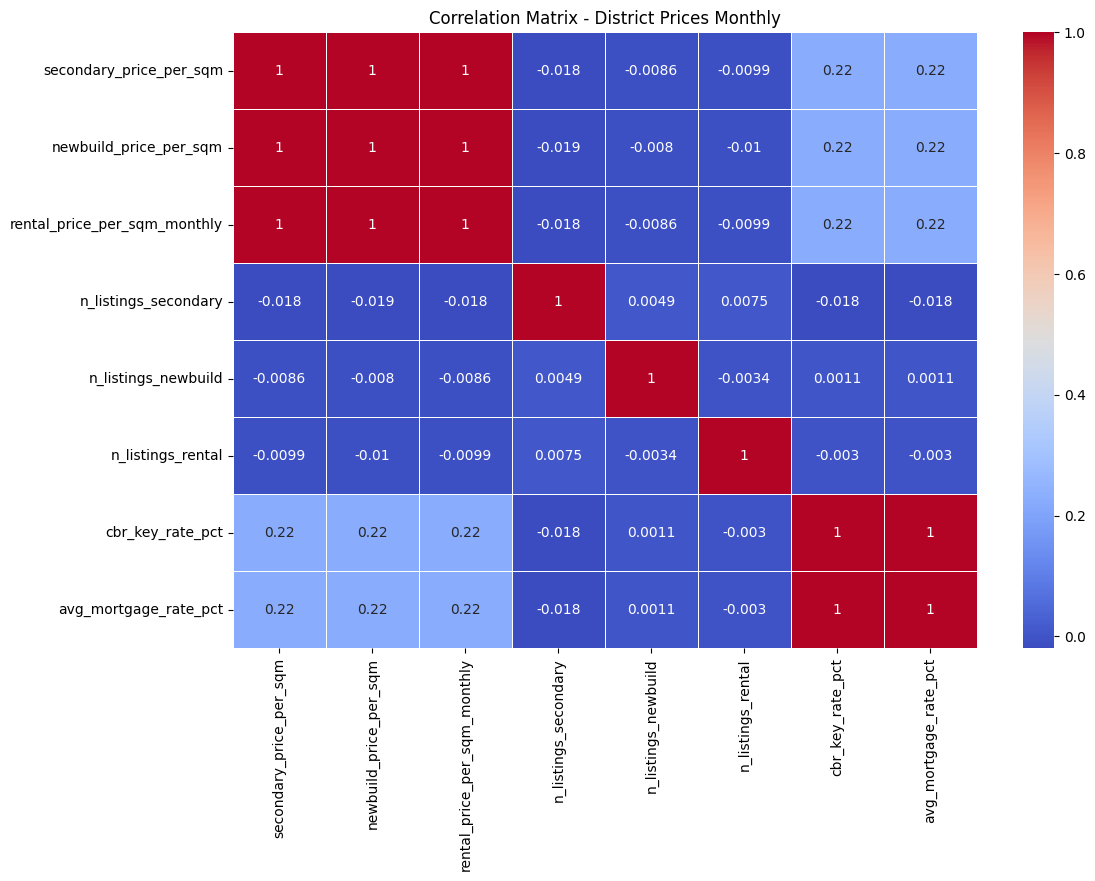

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix - District Prices Monthly")
plt.show()

### working with df2

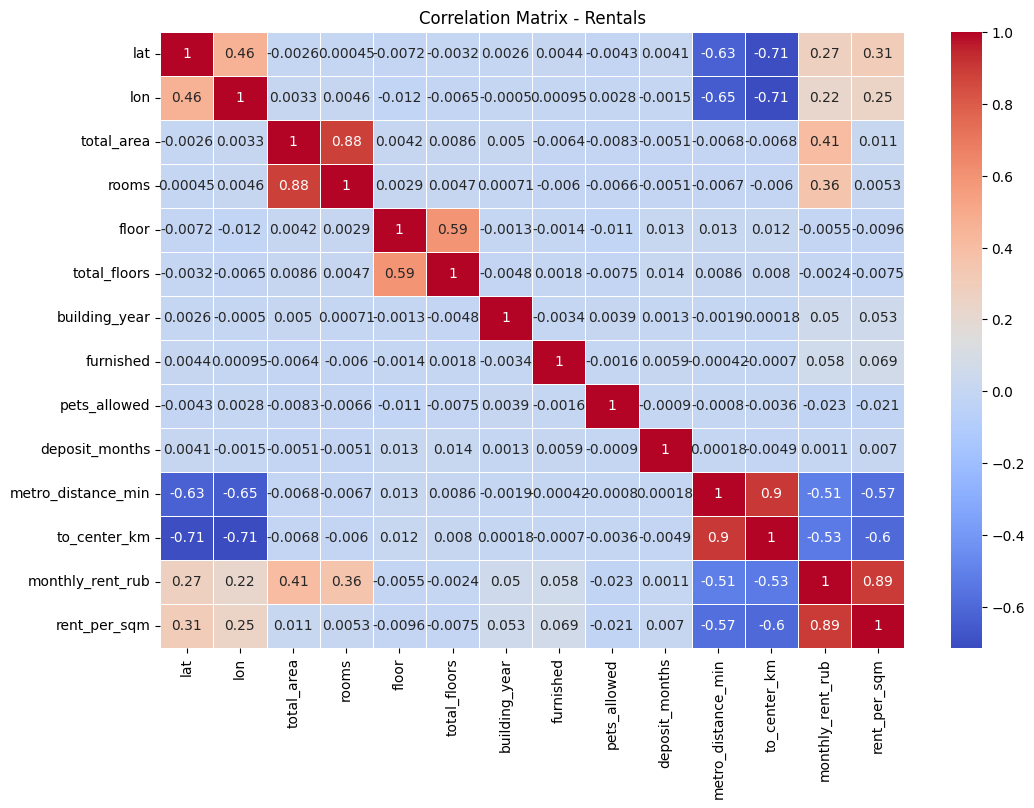

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df2.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix - Rentals")
plt.show()

### working with df3

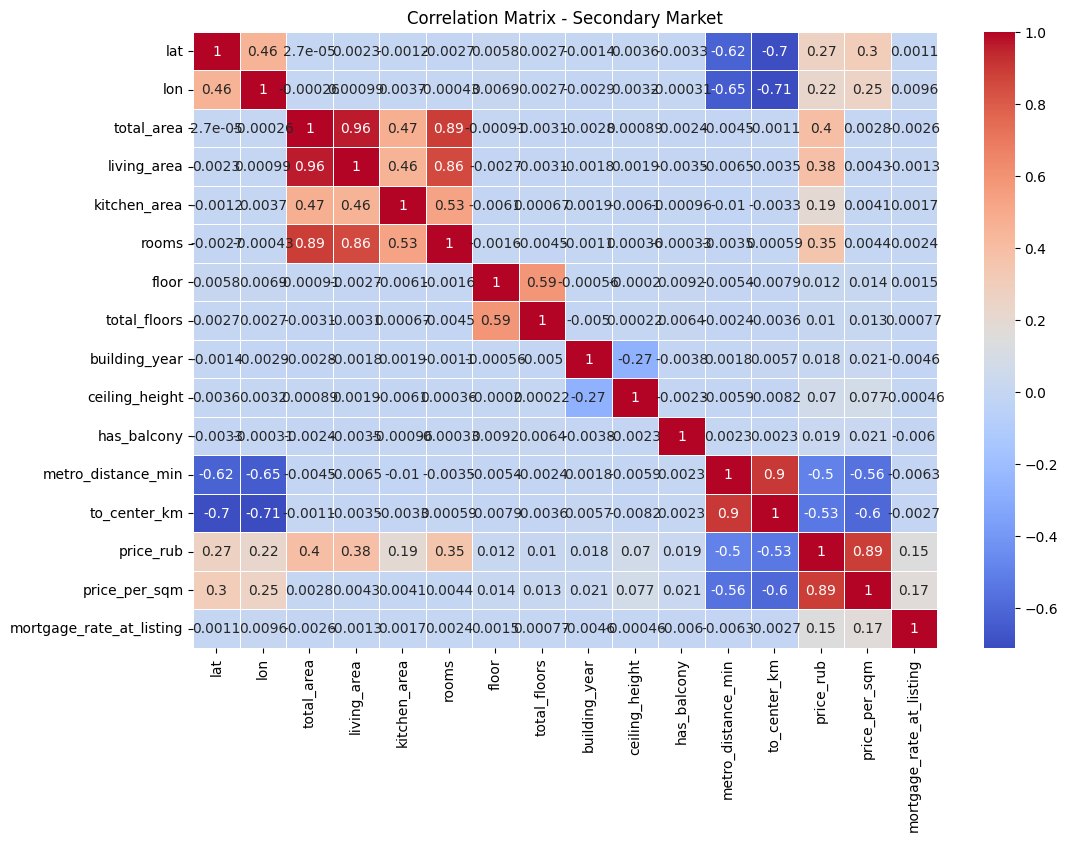

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df3.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix - Secondary Market")
plt.show()

## Covariance matrix

### working with df 

In [33]:
df.cov(numeric_only=True)

,secondary_price_per_sqm,newbuild_price_per_sqm,rental_price_per_sqm_monthly,n_listings_secondary,n_listings_newbuild,n_listings_rental,cbr_key_rate_pct,avg_mortgage_rate_pct
secondary_price_per_sqm,1.527534e+10,1.682535e+10,6.364649e+07,-118573.890467,-23036.734951,-38707.604619,158687.952265,158687.952265
newbuild_price_per_sqm,1.682535e+10,1.860913e+10,7.010478e+07,-137847.112726,-23492.248295,-43357.650042,174280.832130,174280.832130
rental_price_per_sqm_monthly,6.364649e+07,7.010478e+07,2.651907e+05,-494.168174,-95.926322,-161.367305,661.185110,661.185110
n_listings_secondary,-1.185739e+05,-1.378471e+05,-4.941682e+02,2704.055522,5.559136,12.403534,-5.401773,-5.401773
n_listings_newbuild,-2.303673e+04,-2.349225e+04,-9.592632e+01,5.559136,468.960770,-2.320517,0.132207,0.132207
n_listings_rental,-3.870760e+04,-4.335765e+04,-1.613673e+02,12.403534,-2.320517,1008.563508,-0.551142,-0.551142
cbr_key_rate_pct,1.586880e+05,1.742808e+05,6.611851e+02,-5.401773,0.132207,-0.551142,32.631445,32.631445
avg_mortgage_rate_pct,1.586880e+05,1.742808e+05,6.611851e+02,-5.401773,0.132207,-0.551142,32.631445,32.631445


### Covariance Analysis Conclusion

##### The covariance analysis of the district-level pricing dataset reveals that the three pricing variables—**secondary property price per square meter, new-build property price per square meter, and rental price per square meter**—have strong positive covariance values. This indicates that districts with higher resale prices generally also experience higher new-build prices and rental prices.
##### The covariance between property prices and listing counts is predominantly negative, suggesting that areas with a larger number of listings tend to have comparatively lower average prices. This may reflect greater housing supply in those districts.
##### Additionally, the positive covariance between property prices and both the **Central Bank key interest rate** and the **average mortgage rate** indicates that these variables have generally moved in the same direction during the observed period. However, covariance alone does not measure the strength of these relationships and should be interpreted together with the correlation analysis.

##### Overall, the covariance matrix highlights that pricing variables exhibit similar movement patterns, whereas listing activity tends to vary inversely with property prices.

### working with df2

In [36]:
df2.cov(numeric_only=True)

,lat,lon,total_area,rooms,floor,total_floors,building_year,furnished,pets_allowed,deposit_months,metro_distance_min,to_center_km,monthly_rent_rub,rent_per_sqm
lat,0.020819,0.012035,-0.004752,0.000056,-0.004985,-0.002666,0.008544,0.000292,-0.000282,0.000317,-1.519902e+01,-1.304711,1.185332e+03,2.151701e+01
lon,0.012035,0.032679,0.007565,0.000713,-0.010092,-0.006694,-0.002015,0.000078,0.000236,-0.000145,-1.977614e+01,-1.650187,1.206538e+03,2.166032e+01
total_area,-0.004752,0.007565,162.295070,9.737056,0.256400,0.620361,1.428230,-0.037445,-0.048551,-0.035210,-1.450667e+01,-1.104908,1.570314e+05,6.638243e+01
rooms,0.000056,0.000713,9.737056,0.749013,0.012290,0.023017,0.013733,-0.002363,-0.002608,-0.002367,-9.686550e-01,-0.066274,9.304718e+03,2.209548e+00
floor,-0.004985,-0.010092,0.256400,0.012290,23.327016,16.322314,-0.136377,-0.003188,-0.023455,0.033329,1.052917e+01,0.714240,-8.041942e+02,-2.223066e+01
total_floors,-0.002666,-0.006694,0.620361,0.023017,16.322314,32.397084,-0.615842,0.004565,-0.019520,0.042001,8.181382e+00,0.581242,-4.122127e+02,-2.057590e+01
building_year,0.008544,-0.002015,1.428230,0.013733,-0.136377,-0.615842,506.240241,-0.034590,0.040178,0.015998,-7.146573e+00,0.051388,3.397367e+04,5.684852e+02
furnished,0.000292,0.000078,-0.037445,-0.002363,-0.003188,0.004565,-0.034590,0.209146,-0.000346,0.001467,-3.226979e-02,-0.004114,8.025710e+02,1.510152e+01
pets_allowed,-0.000282,0.000236,-0.048551,-0.002608,-0.023455,-0.019520,0.040178,-0.000346,0.211142,-0.000224,-6.206092e-02,-0.021459,-3.148809e+02,-4.527601e+00
deposit_months,0.000317,-0.000145,-0.035210,-0.002367,0.033329,0.042001,0.015998,0.001467,-0.000224,0.292373,1.612227e-02,-0.033870,1.771775e+01,1.831703e+00


### Covariance Analysis Conclusion

##### The covariance analysis of the rental dataset demonstrates that **property size attributes**, including total area and number of rooms, show positive covariance with monthly rent. This suggests that larger residential properties generally command higher rental prices.
##### Distance-related variables, such as **distance to the nearest metro station** and **distance from the city center**, exhibit negative covariance with monthly rent and rent per square meter. This indicates that rental prices generally decrease as properties are located farther from transportation hubs or the city center.
##### Building characteristics, including floor level and total number of floors, display relatively small covariance values with rental prices, suggesting that they have a comparatively weaker influence on rental cost than property size and location.

##### Overall, the covariance analysis indicates that **property size and accessibility are the primary factors influencing rental prices**, while categorical variables such as furnishing status and pet allowance contribute comparatively less to rental price variation.

### working with df3

In [35]:
df3.cov(numeric_only=True)

,lat,lon,total_area,living_area,kitchen_area,rooms,floor,total_floors,building_year,ceiling_height,has_balcony,metro_distance_min,to_center_km,price_rub,price_per_sqm,mortgage_rate_at_listing
lat,0.020735,0.011886,6.682738e-05,3.640473e-03,-4.760443e-04,-4.041887e-04,0.004589,0.002495,-4.870216e-03,0.000113,-0.000206,-4.887263e+00,-1.286301e+00,3.277573e+05,4.884240e+03,9.315875e-04
lon,0.011886,0.032522,-8.259214e-04,1.995434e-03,1.881403e-03,-7.993817e-05,0.006847,0.003162,-1.230959e-02,0.000126,-0.000024,-6.374612e+00,-1.631307e+00,3.460032e+05,5.159517e+03,9.868711e-03
total_area,0.000067,-0.000826,2.996215e+02,1.869702e+02,2.336617e+01,1.573288e+01,-0.087450,-0.353173,-1.154988e+00,0.003409,-0.018032,-4.238980e+00,-2.404255e-01,5.901008e+07,5.535269e+03,-2.528763e-01
living_area,0.003640,0.001995,1.869702e+02,1.256469e+02,1.456512e+01,9.824592e+00,-0.167441,-0.226575,-4.795803e-01,0.004611,-0.017168,-3.979851e+00,-5.037996e-01,3.693921e+07,5.477373e+03,-8.217655e-02
kitchen_area,-0.000476,0.001881,2.336617e+01,1.456512e+01,8.154099e+00,1.554496e+00,-0.095681,0.012430,1.258379e-01,-0.003820,-0.001189,-1.593069e+00,-1.201649e-01,4.709572e+06,1.324545e+03,2.822087e-02
rooms,-0.000404,-0.000080,1.573288e+01,9.824592e+00,1.554496e+00,1.046843e+00,-0.009054,-0.030277,-2.620932e-02,0.000081,-0.000148,-1.939440e-01,7.626760e-03,3.109966e+06,5.057450e+02,1.376083e-02
floor,0.004589,0.006847,-8.745013e-02,-1.674410e-01,-9.568142e-02,-9.054339e-03,30.586088,21.249216,-7.349190e-02,-0.000247,0.021931,-1.612772e+00,-5.554414e-01,5.473374e+05,8.550970e+03,4.818224e-02
total_floors,0.002495,0.003162,-3.531728e-01,-2.265746e-01,1.242985e-02,-3.027662e-02,21.249216,42.666113,-7.738247e-01,0.000311,0.018116,-8.662123e-01,-2.953820e-01,5.566741e+05,9.741461e+03,2.868381e-02
building_year,-0.004870,-0.012310,-1.154988e+00,-4.795803e-01,1.258379e-01,-2.620932e-02,-0.073492,-0.773825,5.555902e+02,-1.392252,-0.038837,2.328463e+00,1.704937e+00,3.575049e+06,5.701213e+04,-6.171555e-01
ceiling_height,0.000113,0.000126,3.409104e-03,4.611162e-03,-3.819599e-03,8.068501e-05,-0.000247,0.000311,-1.392252e+00,0.048769,-0.000221,-7.136563e-02,-2.294732e-02,1.328463e+05,1.930883e+03,-5.826122e-04


### Covariance Analysis Conclusion

##### The covariance analysis of the secondary market dataset indicates that **property size variables**, including total area, living area, and kitchen area, have strong positive covariance with both total property price and price per square meter. This suggests that larger properties are generally associated with higher market values.
##### Location-related variables such as **distance from the metro station** and **distance from the city center** display negative covariance with property prices, indicating that properties located farther from key urban areas generally have lower market values.
##### The analysis also shows positive covariance between floor level, total number of floors, and property prices, although the magnitude is smaller than that observed for property size variables. Mortgage rates exhibit comparatively weak covariance with property prices, suggesting limited direct variation during the observed period.

##### Overall, the covariance matrix demonstrates that **property size and location are the dominant factors associated with property prices in the secondary housing market**, while structural characteristics contribute to a lesser extent.

## Overall Covariance Analysis

### The covariance analysis across all three datasets indicates consistent market behavior within the Russian real estate sector. Property pricing variables generally move together, demonstrating positive covariance across resale, new-build, and rental markets.

### The analyses further reveal that **property size** (such as total area and living area) is positively associated with both selling and rental prices, whereas **distance from transportation facilities and the city center** tends to exhibit negative covariance with property values and rental costs.

### Although covariance effectively identifies the direction in which variables change together, its magnitude depends on the units and scales of the variables. Therefore, the covariance analysis is complemented by the correlation analysis to better understand the strength of the relationships between variables.

### Overall, the covariance matrices provide valuable preliminary insights into the interactions among pricing, location, listing activity, and property characteristics, forming a strong statistical foundation for the subsequent exploratory data analysis and business intelligence tasks.

# EDA

## Scatter plot:

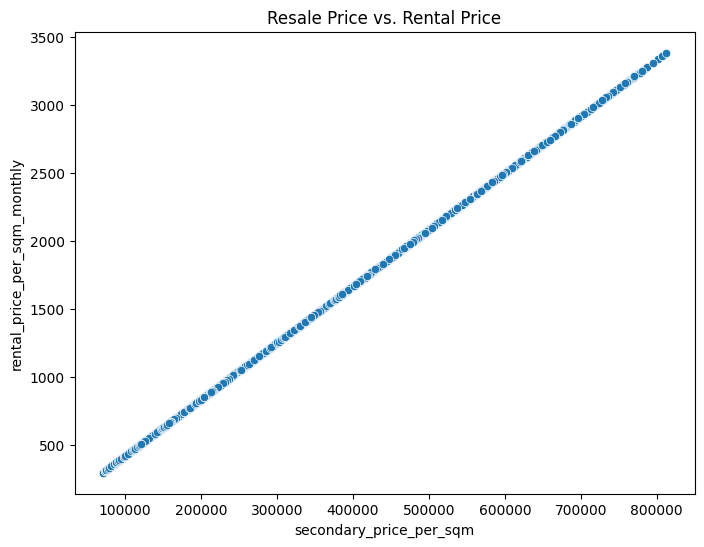

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='secondary_price_per_sqm',
    y='rental_price_per_sqm_monthly',
    data=df
)

plt.title("Resale Price vs. Rental Price")
plt.show()

### conlcusion : The scatter plot shows a strong positive linear relationship between resale price per square meter and rental price per square meter, indicating that districts with higher resale prices generally have higher rental prices.